# Exercício guiado de Machine Learning

## Case: advanced analytics no mercado de vinho
_________

Suponha que você é um cientista de dados que trabalha na área de *advanced analytics* de uma empresa especializada na distribuição e vendas de vinhos tintos. Naturalmente, a empresa está interessada em vender vinhos que sejam percebidos como bons por grande parte do público. Pensando nisso, foi feita uma pesquisa, na qual vinhos tintos com diferentes características físico-químicas foram oferecidos a alguns voluntários, que, após experimentá-los, deram notas de 0 a 10. A base coletada contém as seguintes informações:

- Medidas de 11 variáveis físico-químicas que caracterizam cada amostra (as features do problema):
<br><br>
    - 1 - fixed acidity - medida da acidez devido à presença de ácidos orgânicos de baixa volatilidade (ácido málico, lático, tartárico ou cítrico) no vinho;
    - 2 - volatile acidity - medida da acidez devido a ácidos de baixo peso molecular (sobretudo ácido acético) presentes no vinho, que são responsáveis pelo aroma e gosto de vinagre;
    - 3 - citric acid - medida de ácido cítrico no vinho;
    - 4 - residual sugar - medida de açúcar residual presente no vinho, com origem nos resíduos de açúcar da uva que permanecem no vinho após o fim da fermentação;
    - 5 - chlorides - medida de cloretos (íons de cloro) no vinho;
    - 6 - free sulfur dioxide - medida de dióxido de enxofre livre (isto é, que não está ligado a outras moléculas) no vinho;
    - 7 - total sulfur dioxide - medida de dióxido de enxofre total (livre + porção ligada a outras moléculas) no vinho;
    - 8 - density - medida da densidade do vinho;
    - 9 - pH - medida do pH do vinho;
    - 10 - sulphates - medida de sulfatos (íons SO₄²⁻) no vinho;
    - 11 - alcohol - medida da graduação alcoólica do vinho.
<br><br>
- Além disso, há a variável resposta que no caso é um score numérico:
<br><br>
    - 12 - quality - score numérico de qualidade (de 0 a 10), produzido com base em dados sensoriais.

Com base nestes dados coletados, seu objetivo é produzir um modelo capaz de distinguir vinhos bons de ruins, com base nas medidas de suas características físico-químicas. 

Uma vez que tenhamos este modelo, caso produtoras de vinho ofereçam um novo vinho para ser vendido por sua empresa, será possível decidir de maneira mais direcionada se vale a pena passar a vender este produto ou não, de acordo com a predição de sua qualidade dada pelo modelo.

Dentro deste contexto, seu objetivo como cientista de dados é claro:

> Agregar valor ao negócio, explorando os dados que você tem à disposição.

Na primeira sprint do projeto, você e outros colegas do time de ciência de dados chegaram na seguinte _TO-DO list_ para o desenvolvimento do projeto:

- [ ] Ingestão dos dados e detalhada análise exploratória
- [ ] Formulação do problema
- [ ] Primeiro modelo baseline
- [ ] Iterações pelo ciclo de modelagem
- [ ] Compilação dos resultados para o negócio
- [ ] Comunicação dos resultados

Com base na TO-DO list acima, o time de data science quebrou a análise exploratória em algumas perguntas importantes a serem respondidas, antes da etapa de modelagem.

Agora é com você! Bom trabalho, e divirta-se! :D


_________

*Obs.: Naturalmente, o enunciado acima foi apenas uma historinha que criei pra motivar o problema em um contexto de negócio. Para maiores informações sobre a coleta e origem real dos dados, veja a página do dataset no repositório UCI machine learning repository, [disponível aqui!](https://archive.ics.uci.edu/ml/datasets/wine+quality)* 

_________

Vamos começar pelos primeiros pontos da TO-DO list:

- [ ] Ingestão dos dados e detalhada análise exploratória
- [ ] Formulação do problema

_______

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


1) Leia o arquivo csv `winequality-red.csv`, construindo um Data Frame do pandas. Responda:

- Quantas linhas há no dataset?
- Quantas colunas há no dataset?
- Quais os tipos de dados em cada coluna?
- Há dados nulos (null, missing) na base?

In [26]:
wines_df = pd.read_csv(r'C:\users\jessica\downloads\winequality-red.csv')

In [27]:
wines_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [29]:
wines_df.notna().value_counts()

fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  free sulfur dioxide  total sulfur dioxide  density  pH    sulphates  alcohol  quality
True           True              True         True            True       True                 True                  True     True  True       True     True       1599
Name: count, dtype: int64

In [30]:
wines_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


_______

### Observação importante!

A primeira EDA pode ser feita com toda a amostra de dados que temos disponível, sem problemas.

No entanto, a partir do momento em que chegamos à conclusão de que de fato é necessário construir um modelo, é importante que façamos o **train-test split**, e:

>**Qualquer análise exploratória que, de qualquer maneira, guie o processo de construção do modelo, deve ser feita unicamente com os dados de treino!**

Isso é importante porque, lembre-se, a base de teste tem o único propósito de nos auxiliar a estimar a performance de generalização de nosso modelo, e não deve ser usada em hipótese alguma no passo 1 do ciclo de modelagem (construção do modelo), pois se isso acontecer, estaremos cometendo data leakage, e a estimativa de generalização pode se invalidar!

<Axes: xlabel='quality'>

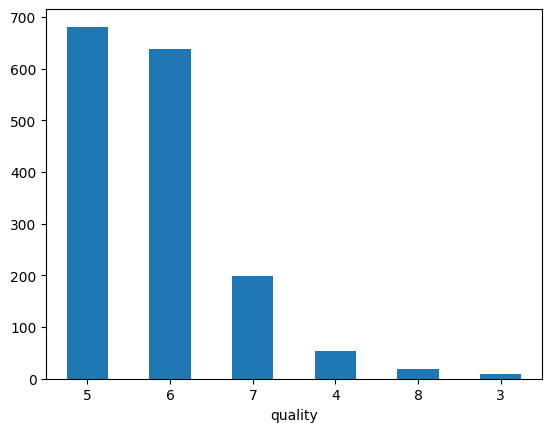

In [31]:
wines_df['quality'].value_counts().plot(kind='bar', rot=0)
#wines_df['quality'].plot(kind='bar')

In [32]:
def wine_class(x):
    if x <= 4:
        return 'bad'
    elif x < 7:
        return 'medium'
    else:
        return 'good'

In [33]:
wines_df['quality'] = wines_df['quality'].map(lambda x: wine_class(x))

In [34]:
wines_df['quality'].value_counts()

quality
medium    1319
good       217
bad         63
Name: count, dtype: int64

In [35]:
wines_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,medium
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,medium
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,medium
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,medium
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,medium


In [36]:
#SEPARAR DF

X = wines_df.drop('quality', axis=1)
y = wines_df['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.70, random_state=42)


_______

2) Utilizando a base de vinhos tintos, estude a distribuição das variáveis numéricas, calculando, para cada coluna, as principais estatísticas descritivas de posição (média, mediana, quartis, etc.) e de dispersão (std, IQR, etc.). Se desejar, visualize as distribuições de cada variável na amostra.

Se houver interesse e importância em identificar/remover outliers, podemos usar métodos mais robustos, como os discutidos [neste post](https://machinelearningmastery.com/model-based-outlier-detection-and-removal-in-python/), ou segundo a própria [documentação do sklearn](https://scikit-learn.org/stable/modules/outlier_detection.html).

In [5]:
x_train.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,1119.000000,1119.000000,1119.000000,1119.000000,1119.000000,1119.000000,1119.000000,1119.000000,1119.000000,1119.000000,1119.000000
mean,8.309562,0.533132,0.270250,2.548302,0.087711,15.920465,46.966488,0.996778,3.314272,0.658820,10.417337
std,1.713899,0.182022,0.195492,1.427730,0.047143,10.273166,33.036693,0.001840,0.153980,0.172242,1.059751
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.370000,8.400000
25%,7.100000,0.400000,0.090000,1.900000,0.071000,7.000000,22.000000,0.995685,3.220000,0.550000,9.500000
50%,7.900000,0.520000,0.260000,2.200000,0.080000,14.000000,38.000000,0.996800,3.310000,0.620000,10.200000
75%,9.200000,0.640000,0.430000,2.600000,0.090000,21.000000,64.000000,0.997845,3.400000,0.730000,11.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000


In [6]:
display(x_train.quantile(0.25) - (1.5 * (x_train.quantile(0.75)) - x_train.quantile(0.25)))
display(x_train.quantile(0.75) + (1.5 * (x_train.quantile(0.75)) - x_train.quantile(0.25)))

fixed acidity            0.400000
volatile acidity        -0.160000
citric acid             -0.465000
residual sugar          -0.100000
chlorides                0.007000
free sulfur dioxide    -17.500000
total sulfur dioxide   -52.000000
density                  0.494602
pH                       1.340000
sulphates                0.005000
alcohol                  2.500000
dtype: float64

fixed acidity            15.900000
volatile acidity          1.200000
citric acid               0.985000
residual sugar            4.600000
chlorides                 0.154000
free sulfur dioxide      45.500000
total sulfur dioxide    138.000000
density                   1.498928
pH                        5.280000
sulphates                 1.275000
alcohol                  18.000000
dtype: float64

In [7]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1119 entries, 925 to 1126
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1119 non-null   float64
 1   volatile acidity      1119 non-null   float64
 2   citric acid           1119 non-null   float64
 3   residual sugar        1119 non-null   float64
 4   chlorides             1119 non-null   float64
 5   free sulfur dioxide   1119 non-null   float64
 6   total sulfur dioxide  1119 non-null   float64
 7   density               1119 non-null   float64
 8   pH                    1119 non-null   float64
 9   sulphates             1119 non-null   float64
 10  alcohol               1119 non-null   float64
dtypes: float64(11)
memory usage: 104.9 KB


In [8]:
x_train_filtered = x_train[x_train['total sulfur dioxide'] <= 148]


In [9]:
x_train_filtered = x_train_filtered[x_train_filtered['free sulfur dioxide'] <= 45]

In [10]:
x_train_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1102 entries, 363 to 1126
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1102 non-null   float64
 1   volatile acidity      1102 non-null   float64
 2   citric acid           1102 non-null   float64
 3   residual sugar        1102 non-null   float64
 4   chlorides             1102 non-null   float64
 5   free sulfur dioxide   1102 non-null   float64
 6   total sulfur dioxide  1102 non-null   float64
 7   density               1102 non-null   float64
 8   pH                    1102 non-null   float64
 9   sulphates             1102 non-null   float64
 10  alcohol               1102 non-null   float64
dtypes: float64(11)
memory usage: 103.3 KB


In [11]:
filtro_sup = x_train_filtered.quantile(0.75) + (1.5 * (x_train_filtered.quantile(0.75)) - x_train_filtered.quantile(0.25))

In [12]:
filtro_sup

fixed acidity            15.900000
volatile acidity          1.200000
citric acid               0.985000
residual sugar            4.600000
chlorides                 0.154000
free sulfur dioxide      45.500000
total sulfur dioxide    134.875000
density                   1.498808
pH                        5.280000
sulphates                 1.275000
alcohol                  18.000000
dtype: float64

In [13]:
#x_train_filtered = x_train[x_train <= filtro_sup]
x_train_filtered = x_train[(x_train[list(filtro_sup.index)] <= filtro_sup.values).all(axis=1)]

In [14]:
x_train_filtered

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
363,12.5,0.460,0.63,2.0,0.071,6.0,15.0,0.99880,2.99,0.87,10.2
906,7.2,0.540,0.27,2.6,0.084,12.0,78.0,0.99640,3.39,0.71,11.0
426,6.4,0.670,0.08,2.1,0.045,19.0,48.0,0.99490,3.49,0.49,11.4
1251,7.5,0.580,0.14,2.2,0.077,27.0,60.0,0.99630,3.28,0.59,9.8
1274,7.8,0.580,0.13,2.1,0.102,17.0,36.0,0.99440,3.24,0.53,11.2
...,...,...,...,...,...,...,...,...,...,...,...
1130,9.1,0.600,0.00,1.9,0.058,5.0,10.0,0.99770,3.18,0.63,10.4
1294,8.2,0.635,0.10,2.1,0.073,25.0,60.0,0.99638,3.29,0.75,10.9
860,7.2,0.620,0.06,2.7,0.077,15.0,85.0,0.99746,3.51,0.54,9.5
1459,7.9,0.200,0.35,1.7,0.054,7.0,15.0,0.99458,3.32,0.80,11.9


In [15]:
#display(x_train_filtered.quantile(0.25) - (1.5 * (x_train_filtered.quantile(0.75)) - x_train_filtered.quantile(0.25)))
#display(x_train_filtered.quantile(0.75) + (1.5 * (x_train_filtered.quantile(0.75)) - x_train_filtered.quantile(0.25)))

In [16]:
x_train_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 981 entries, 363 to 1126
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         981 non-null    float64
 1   volatile acidity      981 non-null    float64
 2   citric acid           981 non-null    float64
 3   residual sugar        981 non-null    float64
 4   chlorides             981 non-null    float64
 5   free sulfur dioxide   981 non-null    float64
 6   total sulfur dioxide  981 non-null    float64
 7   density               981 non-null    float64
 8   pH                    981 non-null    float64
 9   sulphates             981 non-null    float64
 10  alcohol               981 non-null    float64
dtypes: float64(11)
memory usage: 92.0 KB


_______

3) Utilizando a base de vinhos tintos, responda: existe alguma coluna com outliers? Indique qual método de detecção de outliers você utilizou, justificando seu uso.

In [17]:
# Utilizamos o método de IQR superior para identificar OUTLIERS e filtramos todos os valores que estavam acima do limite superior.

Se houver interesse e importância em identificar/remover outliers, podemos usar métodos mais robustos, como os discutidos [neste post](https://machinelearningmastery.com/model-based-outlier-detection-and-removal-in-python/), ou segundo a própria [documentação do sklearn](https://scikit-learn.org/stable/modules/outlier_detection.html).

_______

3) Utilizando a base de vinhos tintos, estude os dados na coluna `quality`, que é a variável resposta do problema. Em particular, responda:

- Essa é uma variável contínua ou discreta?
- Como as notas estão distribuídas? Quais as notas mais/menos comuns?
- Faz sentido discretizar esta variável em dois níveis categóricos? 
    - Se sim, qual seria o valor de corte, e, com este corte, qual é o significado de cada nível categórico?
    - Como estes dois níveis categóricos estão distribuídos?

In [18]:
# target = varíavel discreta
#y.mode() = 5 <- valor com maior repetição
# mais comuns (5, 6) -- menos comuns (3, 8)


<Axes: ylabel='Frequency'>

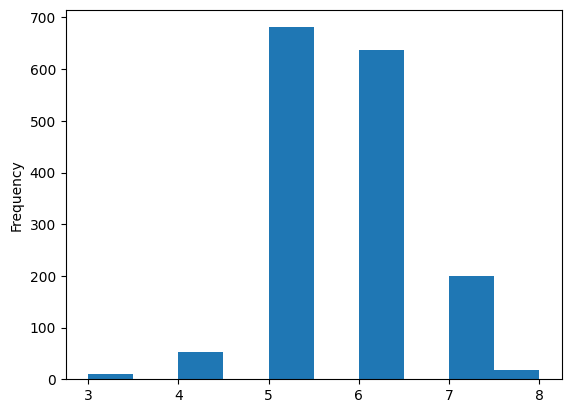

In [19]:
y.plot(kind='hist')

_______

4) Utilizando a base de vinhos tintos, calcule e/ou visualize a correlação (utilizando a relação que achar mais adequada) entre as variáveis na base. 

Em particular, estude a correlação entre as features e o target `quality`, e responda se há correlações fortes.

Plote também a relação entre cada uma das features e o target (na forma de um scatterplot, por exemplo).

Com base nas análises acima, responda: é uma boa ideia modelar o problema como um problema de regressão? Se sim, que métodos de aprendizagem você utilizaria?

In [20]:
df_temp = pd.concat([x_train, y_train], axis=1)

In [21]:
df_temp.corr()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.245763,0.660645,0.122042,0.098989,-0.145343,-0.103373,0.656636,-0.678213,0.163543,-0.044515,0.099203
volatile acidity,-0.245763,1.000000,-0.551099,-0.007040,0.070961,-0.016777,0.072153,0.018237,0.221533,-0.269874,-0.209710,-0.383783
citric acid,0.660645,-0.551099,1.000000,0.173474,0.214821,-0.056900,0.049862,0.368483,-0.533230,0.304638,0.114318,0.196974
residual sugar,0.122042,-0.007040,0.173474,1.000000,0.063200,0.149018,0.165529,0.374609,-0.093322,0.011955,0.051596,0.006776
chlorides,0.098989,0.070961,0.214821,0.063200,1.000000,-0.002880,0.036779,0.190870,-0.260993,0.360577,-0.199969,-0.131160
free sulfur dioxide,-0.145343,-0.016777,-0.056900,0.149018,-0.002880,1.000000,0.668618,-0.027318,0.054144,0.049928,-0.091879,-0.057383
total sulfur dioxide,-0.103373,0.072153,0.049862,0.165529,0.036779,0.668618,1.000000,0.071026,-0.075324,0.032359,-0.230724,-0.201588
density,0.656636,0.018237,0.368483,0.374609,0.190870,-0.027318,0.071026,1.000000,-0.329086,0.129466,-0.472967,-0.188680
pH,-0.678213,0.221533,-0.533230,-0.093322,-0.260993,0.054144,-0.075324,-0.329086,1.000000,-0.191379,0.197447,-0.026850
sulphates,0.163543,-0.269874,0.304638,0.011955,0.360577,0.049928,0.032359,0.129466,-0.191379,1.000000,0.112979,0.243037


AttributeError: PathCollection.set() got an unexpected keyword argument 'annot'

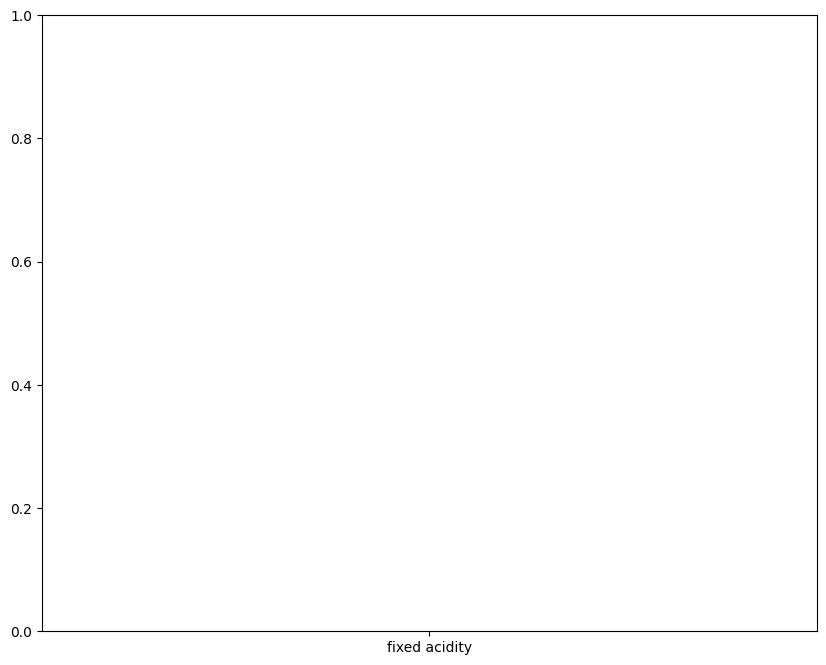

In [30]:
plt.figure(figsize=(10, 8))
sns.scatterplot(df_temp.corr(), annot=True)
plt.show()

In [25]:
correlations = df_temp.corr()

ValueError: x and y must be the same size

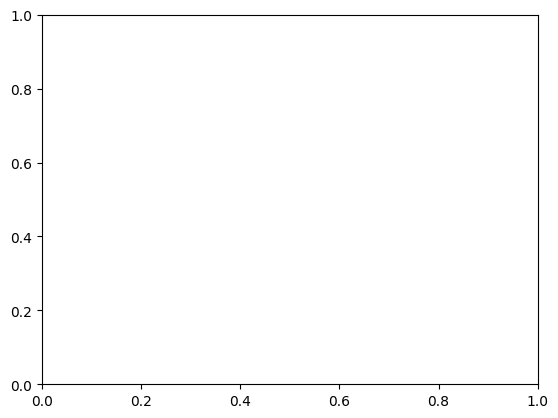

In [28]:
import matplotlib
import matplotlib.pyplot

matplotlib.pyplot.scatter(df_temp.corr(), y)

_______

5) Utilizando a base de vinhos tintos, calcule e/ou visualize (em um gráfico de barras, ou como preferir) o intervalo de confiança de 90% para a média de cada uma das variáveis físico-químicas, agrupadas pelos níveis categóricos da variável resposta `quality`. Que conclusões são possíveis tirar destes gráficos?

Sugestão: utilizar o seaborn para a visualização.

_______

6) Utilizando a base de vinhos tintos, discretize a variável resposta `quality` em dois níveis categóricos para transformar o problema em um problema de classificação binária. Como valor de corte, utilize aquele que seja tal que os dois níveis categóricos estejam o mais igualmente distribuídos possível (isto é, um corte que minimize o desbalanceamento das classes). Sugestão: teste todos os valores de corte possíveis (não são muitos!)

Após a determinação do valor de corte que satisfaça às condições acima, responda: o que, qualitativamente, cada uma das duas classes representa? Esta discretização faz sentido? Se sim, para facilitar análises posteriores, nomeie as classes de acordo.

Dica: vamos usar esta nova variável resposta binária nas análises dos próximos exercícios, então sugiro que o dataframe com esta variável seja salvo num arquivo, para que ele possa ser simplesmente lido posteriormente.

_______

7) Considere a base de vinhos tintos com a variável `quality` discretizada em duas classes ("bom" para nota maior que 5; "ruim" caso contrário). Vamos agora analisar a separabilidade das duas classes do problema. Para isso, faça:

- Visualize as distribuições das features, com indicação dos diferentes níveis categóricos do target;
- Visualize as projeções dos dados em cada um dos subespaços de pares de features, com indicação dos níveis categóricos do target;

Responda: com base nesta análise, o problema é linearmente separável?

O problema tem separabilidade não trivial. Com base nisso, é de se esperar que métodos lineares não tenham uma performance muito boa. Esta observação indica que, provavelmente, precisaremos de estimadores mais complexos para caputrar o padrão refletido na amostra de treino. Claro, testaremos isso tudo no ciclo de modelagem a seguir, mas é bom já termos alguma expectativa para os resultados que iremos obter.

_______

8) Considere a base de vinhos tintos com a variável `quality` discretizada em duas classes. Separe o dataset em dados de treino (70%) e de teste (30%), estratifidando pelo target. Utilize `random_state=42` como seed, para fins de reprodutibilidade.

Apenas com os dados de treino, calcule as componentes principais do espaço de features, e responda:

- Quantas componentes principais são necessárias para que pelo menos 90% da variância do dataset seja explicada?
- Faça um scatterplot das duas primeiras componentes principais, com indicação dos níveis categóricos do target;
    - No sub-espaço das duas primeiras componentes principais, há separabilidade linear dos dados?

Dica: utilize as ferramentas do scikit-learn.

Essa projeção também é um indicativo de que nosso problema não tem uma separabilidade linear trivial. Provavelmente, precisaremos criar modelos mais complexos!

_______

9) Considere a base de vinhos tintos com a variável `quality` discretizada em duas classes. Separe o dataset em dados de treino (70%) e de teste (30%), estratifidando pelo target. Utilize `random_state=42` como seed, para fins de reprodutibilidade. Usando os dados de treino, faça:

- Agrupe os dados pelos níveis categóricos do target, e calcule a média de cada uma das features;

- Faça um teste de hipótese para determinar se, a um nível de significância de 5%, há diferença na média de cada uma das sub-amostras de cada classe, para todas as variáveis;

- Compare a distribuição das features analisando o boxplot de cada uma, separados pelas duas classes do target.

Dica: utilize as ferramentas do scipy e do scikit-learn.

__________
__________
__________


Uma vez que você tenha respondido às questões anteriores, você completou, talvez sem perceber, o importantíssimo (e longo!) processo de análise exploratória dos dados (EDA, do termo inglês, *exploratory data analysis*)!

De fato, a etapa de EDA é importantíssima em todo projeto de ciência de dados, pois é apenas explorando os dados que de fato nos familiarizamos com o contexto do problema com o qual estamos trabalhando, o que é fundamental para o sucesso das próximas etapas, que pode envolver a criação e avaliação de modelos de machine learning, que é exatamente o que faremos agora, endereçando os próximos pontos da TO-DO list:

- [ ] Primeiro modelo baseline
- [ ] Iterações pelo ciclo de modelagem

Vamos lá!

___________

Vamos começar com o baseline - uma regressão logística, modelo linear simples.

### Passo 1 - Construção do modelo

In [50]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression

### Passo 2 - Avaliação do modelo

Agora vamos estimar a generalização do modelo com os dados de teste!

Lembre-se: o objetivo é avaliar onde estamos no tradeoff viés-variância (sobretudo no caso de alta variância (overfit)).

In [52]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

Claro, é importante que calculemos as métricas de avaliação tanto na base de treino quanto na base de teste, pra aferir se o modelo está overfitado (isto é, aferir a variância):

Podemos dizer claramente que o modelo não está overfitado.

Inclusive, há até um fenômeno interessante: o modelo tem métricas melhores no teste do que no treino!

Esse é um sinal claro de que o modelo sofre de underfitting -- o que faz sentido, dado que a regressão logística (um modelo linear) é demasiadamente simples para os nossos dados!

Como baseline, funciona muito bem. 

Nosso objetivo agora vai ser melhorar esta performance, aumentando um pouco a complexidadce da hipótese!

### Agora, vamos entrar no ciclo, testando alguns estimadores mais complexos:

## Entrando no ciclo de modelagem!

Vamos agora treinar e avaliar sistematicamente diversos modelos.

Vamos criar uma função para o experimento:

Legal, já temos alguns resultados interessantes, muito melhores que os que tínhamos inicialmente!

Mas ainda estamos com os hiperparâmetros default dos estimadores. É possível melhorarmos os resultados, se otimizarmos os hiperparâmetros dos estimadores!

____________

### Otimização de hiperparâmetros

- Começo com um random search, pra identificar **regiões promissoras no espçao de hiperparâmetros**;

- Depois de encontrar estas regiões promissoros, uso o grid search pra fazer um **ajuste fino** nas redondezas da região promissora.

Tudo isso, se for relativamente rápido de passar pelos processos acima. 

Se demorar muito (é o caso, por exemplo, de bases muito grandes), podemos partir direto pra otimização baeysiana.

Vamos ilustrar este procedimento apenas com o Random Forest, para definirmos as ferramentas que podem ser utilizadas para os demais estimadores também.

Vamos alterar este comportamento, a partir da função a seguir, que considera também o gap (delta) para decidir a melhor combinação de hiperparâmetros: